In [2]:
from transformers import pipeline
from huggingface_hub import list_models

# Функция проверки существования модели
def check_model_exists(model_name):
    try:
        # Пытаемся загрузить модель
        classifier = pipeline("text-classification", model=model_name)
        print(f"Модель '{model_name}' найдена и загружена")
        return classifier
    except Exception as e:
        print(f"Модель '{model_name}' не найдена")
        print(f"Ошибка: {str(e)[:100]}")
        return None

# Проверяем модель
model_name = "Sengil/ModernBERT-NewsClassifier-EN-small"
classifier = check_model_exists(model_name)
    
# Тестируем
text = "The President pledges new infrastructure initiatives amid economic concerns."
outputs = classifier(text)
print(f"\nРезультат: {outputs}")


Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

Модель 'Sengil/ModernBERT-NewsClassifier-EN-small' найдена и загружена

Результат: [{'label': 'POLITICS', 'score': 0.8993507027626038}]


In [3]:
text = "Australia’s two biggest car-share companies, GoGet and Flexicar, have removed fuel cards from their Melbourne vehicles after a spate of break-ins and thefts that a senior GoGet exeutive described as one of the dumbest crimes ever.The change will force users of share cars to pay for fuel themselves before seeking reimbursement, leaving them temporarily out of pocket amid record-high fuel prices caused by the US-Israel war on Iran."
outputs = classifier(text)
print(outputs)

[{'label': 'BUSINESS', 'score': 0.9955458641052246}]


In [7]:
from transformers import (
    TokenClassificationPipeline,
    AutoModelForTokenClassification,
    AutoTokenizer,
)
from transformers.pipelines import AggregationStrategy
import numpy as np


class KeyphraseExtractionPipeline(TokenClassificationPipeline):
    def __init__(self, model, *args, **kwargs):
        super().__init__(
            model=AutoModelForTokenClassification.from_pretrained(model),
            tokenizer=AutoTokenizer.from_pretrained(model),
            *args,
            **kwargs
        )

    def postprocess(self, all_outputs, **kwargs):  
        results = super().postprocess(
            all_outputs=all_outputs, 
            aggregation_strategy=AggregationStrategy.FIRST,
            **kwargs
        )

        words = []
        for result in results:
            word = result.get("word", "").strip()
            word = word.replace("##", "")
            if word and len(word) > 1 and word not in words:
                words.append(word)
        return np.unique(words)

model_name = "ml6team/keyphrase-extraction-distilbert-kptimes"
extractor = KeyphraseExtractionPipeline(model=model_name)

text = "The study of machine learning and deep learning has revolutionized artificial intelligence."
keyphrases = extractor(text)

print(f"Текст: {text}")
print(f"Ключевые фразы: {keyphrases}")

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Текст: The study of machine learning and deep learning has revolutionized artificial intelligence.
Ключевые фразы: ['artificial intelligence.']


In [8]:
text = """
The Indian singer Asha Bhosle, whose voice defined Bollywood cinema and whose career spanned almost eight decades, has died in Mumbai at the age of 92.
Bhosle, who recorded more than 12,000 songs, became her country’s pre-eminent exponent of playback singing – recording tracks that were then lip-synced on film by actors. She also boldly embraced cabaret and western-influenced melodies to forge a distinctive musical identity.
News of her death prompted tributes and fond memories from politicians, artists and sports stars.
India’s prime minister, Narendra Modi, said he was deeply saddened by her death. “Her extraordinary musical journey, spanning decades, enriched our cultural heritage and touched countless hearts across the world,” he said. “She will continue to inspire generations and her songs will forever echo in people’s lives.”
""".replace("\n", " ")

keyphrases = extractor(text)

print(keyphrases)

['asha bhosle,' 'bollywood']


In [13]:
!pip install --upgrade tqdm
# from transformers import pipeline

# # Без лишних манипуляций
# nlp = pipeline("ner", model="dslim/bert-base-NER")

# example = "My name is Wolfgang and I live in Berlin"
# ner_results = nlp(example)

# print(ner_results)

  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.67.1
    Uninstalling tqdm-4.67.1:
      Successfully uninstalled tqdm-4.67.1


In [19]:
from transformers import AutoTokenizer, AutoModelForTokenClassification
from transformers import pipeline

tokenizer = AutoTokenizer.from_pretrained("dslim/bert-base-NER")
model = AutoModelForTokenClassification.from_pretrained("dslim/bert-base-NER")

nlp = pipeline("ner", model=model, tokenizer=tokenizer)

news2 = """
Millionaires fund last-ditch attempt to save humpback whale stranded in Germany
A last-ditch effort to rescue a wayward whale that has transfixed Germans for weeks has begun in the Baltic Sea despite criticism it has little chance of success and could further harm the 12-tonne creature.
The male humpback whale was first spotted last month near Timmendorfer Strand on the northern coast of Germany. It has repeatedly become stranded and then freed itself after human assistance but it is now stranded again, with rescuers saying it is fighting a losing battle for its life.
But just as regional officials appeared ready to admit defeat and allow the stricken mammal to die, two multimillionaires came forward with funds to mount an 11th-hour rescue mission for which they won state approval.
""".replace("\n", " ")

ner_results2 = nlp(news2)
print(ner_results2)

AttributeError: 'tqdm' object has no attribute 'disable'

In [21]:
# Ячейка 1: Фикс tqdm (обязательно перед всем!)
import sys
import types

class SafeTqdm:
    def __init__(self, *args, **kwargs):
        self.disable = True
        self.total = 0
        self.n = 0
    def __enter__(self):
        return self
    def __exit__(self, *args, **kwargs):
        pass
    def update(self, *args, **kwargs):
        pass
    def close(self):
        pass
    def set_description(self, *args, **kwargs):
        pass
    def set_postfix(self, *args, **kwargs):
        pass

sys.modules['tqdm'] = type('tqdm', (), {'tqdm': SafeTqdm, '__version__': '4.64.1'})
sys.modules['tqdm.notebook'] = sys.modules['tqdm']
sys.modules['tqdm.auto'] = sys.modules['tqdm']


In [2]:
import pandas as pd
import numpy as np
import torch
from transformers import pipeline
import warnings
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["DISABLE_TQDM"] = "1"  #


warnings.filterwarnings("ignore", category=UserWarning, module="tqdm")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"


In [3]:
df_news = pd.read_csv('2_5406779534018124482.csv')
print(f"Загружено {len(df_news)} новостей")
df_news

Загружено 10 новостей


,,,,News;
Prince Harry and his wife Meghan,Duchess of Sussex,both revealed more of the unhappiness they experienced as working royals on Thursday,with Harry saying he didn’t want “this job” after his mother died and Meghan claiming she “was the most trolled person in the entire world.” Harry has spoken extensively about the devastating impact of his mother’s death,citing it as the reason for his protectivenes...
The South African leftwing politician Julius Malema has been sentenced to five years in prison for firing a rifle in the air at a political rally in 2018.;,NaN,NaN,NaN,NaN
Three people were killed in a US strike on another alleged drug-trafficking boat,the fifth such deadly attack in as many days,military officials have announced.;,NaN,NaN
But the trip,and a meeting with his Chinese counterpart,Xi Jinping,was kicked back by several weeks after Trump decided to launch strikes with Israel against Iran,starting a war in the Middle East that has ca...
Australia’s two biggest car-share companies,GoGet and Flexicar,have removed fuel cards from their Melbourne vehicles after a spate of break-ins and thefts that a senior GoGet executive described as “one of the dumbest crimes ever”.;,NaN,NaN
A last-ditch effort to rescue a wayward whale that has transfixed Germans for weeks has begun in the Baltic Sea despite criticism it has little chance of success and could further harm the 12-tonne creature.;,NaN,NaN,NaN,NaN
More than 100 writers have quit the historic French publishing house Grasset in protest at its conservative billionaire owner;,NaN,NaN,NaN,NaN
Bhosle,who recorded more than 12,000 songs,became her country’s pre-eminent exponent of playback singing – recording tracks that were then lip-synced on film by actors. She also boldly embraced cabaret and western-influenced melodies to forge a distinctive musical identity. News of her death prompted tributes and fond memories from politicians,artists and sports stars.;
Senate Democrats move to stall Trump’s ‘absurd’ bid to install new Fed chair. Democratic lawmakers urged Republican leaders to postpone the confirmation hearing of Kevin Warsh. Democratic lawmakers on the Senate banking committee urged its Republican leadership on Thursday to postpone the planned confirmation hearing for Kevin Warsh,the financial former Fed governor Trump has nominated to replace Jerome Powell as Fed chair.;,NaN,NaN,NaN
Young men are now more likely than young women in the US to say religion plays a major role in their lives,according to the newest findings from Gallup. In earlier measurements,young men and women were essentially tied on this indicator of religiosity. That balance has now shifted,with young men pulling ahead by a statistically meaningful margin.;,NaN


In [26]:
!pip install --upgrade tqdm huggingface_hub --force-reinstall

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
   ---------------------------------------- 0.0/645.5 kB ? eta -:--:--
   ---------------------------------------- 0.0/645.5 kB ? eta -:--:--
   ---------------------------------------- 0.0/645.5 kB ? eta -:--:--
   ---------------------------------------- 0.0/645.5 kB ? eta -:--:--
   ---------------------------------------- 0.0/645.5 kB ? eta -:--:--
   ---------------------------------------- 0.0/645.5 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/645.5 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/645.5 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/645.5 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/645.5 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/645.5 kB ? eta -:--:--
   ---------------- ---

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mdit-py-plugins 0.3.0 requires markdown-it-py<3.0.0,>=1.0.0, but you have markdown-it-py 4.0.0 which is incompatible.
s3fs 2025.3.2 requires fsspec==2025.3.2.*, but you have fsspec 2026.3.0 which is incompatible.
streamlit 1.45.1 requires packaging<25,>=20, but you have packaging 26.1 which is incompatible.


In [4]:
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

In [5]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [6]:
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM
)
import torch

tokenizer_bart = AutoTokenizer.from_pretrained("facebook/bart-large-cnn")
model_bart = AutoModelForSeq2SeqLM.from_pretrained("facebook/bart-large-cnn")

tokenizer_t5 = AutoTokenizer.from_pretrained("t5-small")
model_t5 = AutoModelForSeq2SeqLM.from_pretrained("t5-small")

sentiment = pipeline("text-classification", 
                    model="cardiffnlp/twitter-roberta-base-sentiment")

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
def summarize_bart(text, max_length=50, min_length=10):
    inputs = tokenizer_bart(text, return_tensors="pt", max_length=1024, truncation=True)
    summary_ids = model_bart.generate(
        inputs.input_ids, 
        max_length=max_length, 
        min_length=min_length,
        length_penalty=2.0,
        num_beams=4,
        early_stopping=True
    )
    return tokenizer_bart.decode(summary_ids[0], skip_special_tokens=True)

def summarize_t5(text, max_length=50, min_length=10):
    text = "summarize: " + text
    inputs = tokenizer_t5(text, return_tensors="pt", max_length=1024, truncation=True)
    summary_ids = model_t5.generate(
        inputs.input_ids,
        max_length=max_length,
        min_length=min_length,
        length_penalty=2.0,
        num_beams=4
    )
    return tokenizer_t5.decode(summary_ids[0], skip_special_tokens=True)



text = "Europe is a continent located entirely in the Northern Hemisphere and mostly in the Eastern Hemisphere."

print("BART:", summarize_bart(text))
print("T5:", summarize_t5(text))
print("Sentiment:", sentiment("I love this!")[0])

BART: Europe is a continent located entirely in the Northern Hemisphere and mostly in the Eastern Hemisphere.
T5: Europe is a continent located entirely in the northern Hemisphere and mostly in the eastern Hemisphere.
Sentiment: {'label': 'LABEL_2', 'score': 0.987804651260376}


In [9]:
print("Колонки df_news:")
print(df_news.columns.tolist())
print("Первые строки:")
print(df_news.head(2))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from transformers import pipeline


Колонки df_news:
['News;']
Первые строки:
                                                                                                                                                                                                                        News;
Prince Harry and his wife Meghan                   Duchess of Sussex  both revealed more of the unhappiness they exp... with Harry saying he didn’t want “this job” aft...   citing it as the reason for his protectivenes...
The South African leftwing politician Julius Ma... NaN               NaN                                                NaN                                                                                               NaN


In [10]:
# Автоопределение колонок
TEXT_COL = next((col for col in ['text', 'content', 'body', 'description'] if col in df_news.columns), df_news.columns[0])
TITLE_COL = next((col for col in ['title', 'headline', 'name'] if col in df_news.columns), None)

print(f"TEXT_COL = '{TEXT_COL}'")
if TITLE_COL:
    print(f"TITLE_COL = '{TITLE_COL}'")
else:
    print("TITLE_COL не найден")
print(df_news.columns.tolist())
print(f"Размер: {df_news.shape}")

possible_text_cols = ['text', 'content', 'body', 'description', 'news_text', 'article']
TEXT_COL = next((col for col in possible_text_cols if col in df_news.columns), df_news.columns[0])

possible_title_cols = ['title', 'headline', 'name', 'header']
TITLE_COL = next((col for col in possible_title_cols if col in df_news.columns), None)

print(f"TEXT_COL = '{TEXT_COL}'")
if TITLE_COL:
    print(f"TITLE_COL = '{TITLE_COL}'")

df_news_clean = df_news.dropna(subset=[TEXT_COL]).reset_index(drop=True)
df_news_clean[TEXT_COL] = df_news_clean[TEXT_COL].astype(str)


print(df_news_clean[[TEXT_COL]].head())


TEXT_COL = 'News;'
TITLE_COL не найден
['News;']
Размер: (10, 1)
TEXT_COL = 'News;'
                                               News;
0   citing it as the reason for his protectivenes...
1   starting a war in the Middle East that has ca...
2                         artists and sports stars.;


In [21]:
test_samples = []
if len(df_news) > 0:
    sample1 = str(df_news[TEXT_COL].iloc[0])[:400]
    test_samples.append(sample1)
if len(df_news) > 1:
    sample2 = str(df_news[TEXT_COL].iloc[1])[:400]
    test_samples.append(sample2)
test_samples.append("Europe is a continent located entirely in the Northern Hemisphere.")
for i, text in enumerate(test_samples[:2]):
    print(f"BART:{summarize_bart(text)}")
    print(f"T5:{summarize_t5(text)}")


BART:citing it as the reason for his protectiveness over his wife and young family.
T5:citing it as the reason for his protectiveness over his wife and young family. citing it as the reason for his protectiveness over his wife and young family.
BART:
T5:


In [12]:

def clean_dataset(df):
    df_clean = df.copy()
    for col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('').astype(str)
    
    df_clean = df_clean[df_clean.iloc[:, 0].str.len() > 10]  # Минимум 10 символов
    return df_clean.reset_index(drop=True)

TEXT_COL = next((col for col in ['text', 'content', 'body'] if col in df_news.columns), df_news.columns[0])
TITLE_COL = next((col for col in ['title', 'headline'] if col in df_news.columns), None)

print(f"TEXT_COL='{TEXT_COL}'")

df_news_clean = clean_dataset(df_news)
print(f"Очищено: {len(df_news_clean)} строк (было {len(df_news)})")

print("Первые строки после очистки:")
for i in range(min(3, len(df_news_clean))):
    print(f"{i}: '{df_news_clean[TEXT_COL].iloc[i][:100]}...'")
    

TEXT_COL='News;'
Очищено: 3 строк (было 10)
Первые строки после очистки:
0: ' citing it as the reason for his protectiveness over his wife and young family.;...'
1: ' starting a war in the Middle East that has caused a global energy crisis and roiled diplomatic rela...'
2: ' artists and sports stars.;...'


In [13]:
def summarize_bart(text, max_length=80, min_length=20):
    try:
        clean = str(text).strip()
        clean = re.sub(r'nan|NaN|None|null', '', clean)
        clean = re.sub(r'\s+', ' ', clean)
        
        if len(clean) < 50:
            return clean[:100]
        
        if len(clean) > 1024:
            clean = clean[:1024]
        
        inputs = tokenizer_bart(clean, return_tensors="pt", truncation=True, max_length=1024)
        outputs = model_bart.generate(
            inputs.input_ids,
            max_length=max_length,
            min_length=min_length,
            num_beams=4,
            length_penalty=2.0,
            early_stopping=True
        )
        result = tokenizer_bart.decode(outputs[0], skip_special_tokens=True)
        return result if len(result) > 10 else clean[:80]
    except Exception as e:
        print(f"BART error: {e}")
        return text[:100]

def summarize_t5(text, max_length=80, min_length=20):
    try:
        clean = str(text).strip()
        clean = re.sub(r'nan|NaN|None|null', '', clean)
        clean = re.sub(r'\s+', ' ', clean)
        
        if len(clean) < 50:
            return clean[:100]
        
        prompt = f"summarize: {clean[:512]}"
        inputs = tokenizer_t5(prompt, return_tensors="pt", truncation=True, max_length=512)
        outputs = model_t5.generate(
            inputs.input_ids,
            max_length=max_length,
            min_length=min_length,
            num_beams=4,
            early_stopping=True
        )
        result = tokenizer_t5.decode(outputs[0], skip_special_tokens=True)
        return result if len(result) > 10 else clean[:80]
    except Exception as e:
        print(f"T5 error: {e}")
        return text[:100]


In [15]:
import re
for i in range(min(3, len(df_news_clean))):
    text = df_news_clean[TEXT_COL].iloc[i]
    title = TITLE_COL and df_news_clean[TITLE_COL].iloc[i] or ""
    
    print(f"Оригинал ({len(text)} символов): {text[:80]}...")
    print(f"BART: {summarize_bart(f'{title}. {text}')}")
    print(f"T5:  {summarize_t5(f'{title}. {text}')}")
    

Оригинал (80 символов):  citing it as the reason for his protectiveness over his wife and young family.;...
BART: . citing it as the reason for his protectiveness over his wife and young. family.
T5:  citing it as the reason for his protectiveness over his wife and young family. citing it as the reason for his protectiveness over his wife and young family.
Оригинал (124 символов):  starting a war in the Middle East that has caused a global energy crisis and ro...
BART: . starting a war in the Middle East that has caused a global energy crisis. and roiled diplomatic relations across the board.
T5:  starting a war in the Middle East that has caused a global energy crisis and roiled diplomatic relations across the board.
Оригинал (27 символов):  artists and sports stars.;...
BART: . artists and sports stars.;
T5:  . artists and sports stars.;


In [16]:
def full_analysis(df_clean, n=3):
    results = []
    for i in range(min(n, len(df_clean))):
        text = df_clean[TEXT_COL].iloc[i][:600]
        title = TITLE_COL and df_clean[TITLE_COL].iloc[i][:60] or f"Новость {i+1}"
        
        bart = summarize_bart(f"{title}. {text}")
        t5 = summarize_t5(f"{title}. {text}")
        sent = sentiment(f"{title}. {text}"[:256])[0]
        
        results.append({
            'title': title,
            'bart': bart,
            't5': t5,
            'sentiment': sent['label'],
            'score': f"{sent['score']:.2f}"
        })
    return pd.DataFrame(results)

df_results = full_analysis(df_news_clean, 3)
df_results


,title,bart,t5,sentiment,score
0,Новость 1,Не. citing it as the reason for his protective...,овост 1. citing it as the reason for his prote...,LABEL_1,0.85
1,Новость 2,Russian President Vladimir Putin has declared ...,овост 2. starting a war in the Middle East tha...,LABEL_0,0.84
2,Новость 3,Новость 3. artists and sports stars.;,Новость 3. artists and sports stars.;,LABEL_1,0.88


In [17]:
class CustomMHA(nn.Module):
    def __init__(self, d_model=128, n_heads=8):
        super().__init__()
        self.d_k = d_model // n_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)
    
    def forward(self, x):
        B, T, C = x.shape
        q = self.w_q(x).view(B,T,8,self.d_k).transpose(1,2)
        k = self.w_k(x).view(B,T,8,self.d_k).transpose(1,2)
        v = self.w_v(x).view(B,T,8,self.d_k).transpose(1,2)
        scores = torch.matmul(q, k.transpose(-2,-1)) / np.sqrt(self.d_k)
        attn = F.softmax(scores, dim=-1)
        out = torch.matmul(attn, v).transpose(1,2).contiguous().view(B,T,C)
        return self.w_o(out), attn[0,0]

mha = CustomMHA()
test = torch.randn(1,20,128)
_, weights = mha(test)


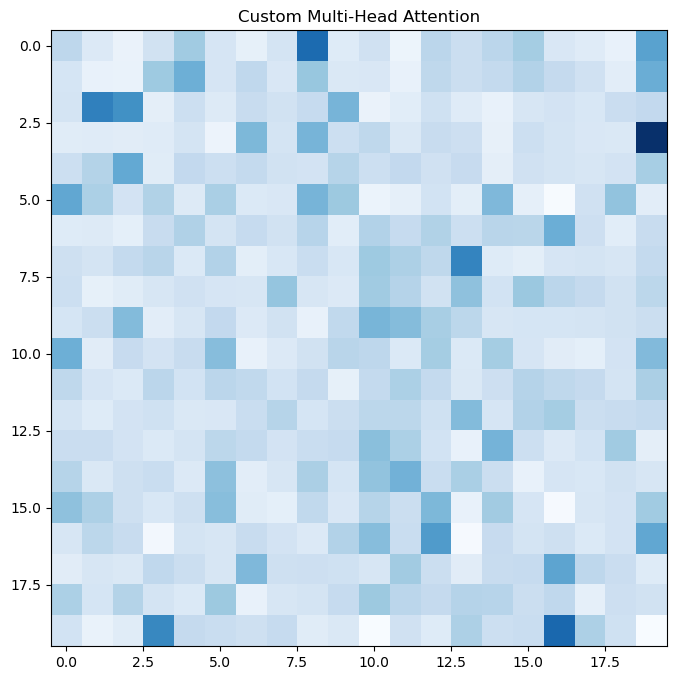

In [18]:
plt.figure(figsize=(10,8))
plt.imshow(weights.detach().numpy(), cmap='Blues')
plt.title('Custom Multi-Head Attention')
plt.show()
